In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
df = pd.read_csv("synthetic_toxicity_dataset_10000.csv")

X = df.drop("toxicity", axis=1)
y = df["toxicity"]

In [3]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [18]:

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.03,
    objective="multi:softmax",
    num_class=3,
    random_state=42
)

In [19]:
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [20]:
y_test_decoded = le.inverse_transform(y_test)
y_pred_decoded = le.inverse_transform(y_pred)
print("Accuracy:", accuracy_score(y_test_decoded, y_pred_decoded))
print(classification_report(y_test_decoded, y_pred_decoded))

Accuracy: 0.9665
              precision    recall  f1-score   support

        High       0.98      0.99      0.98      1471
         Low       0.78      0.64      0.71        28
      Medium       0.94      0.93      0.93       501

    accuracy                           0.97      2000
   macro avg       0.90      0.85      0.87      2000
weighted avg       0.97      0.97      0.97      2000



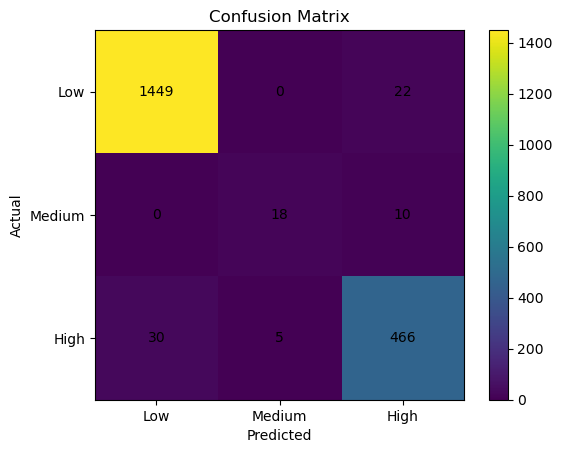

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np


cm = confusion_matrix(y_test_decoded, y_pred_decoded)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["Low", "Medium", "High"]
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

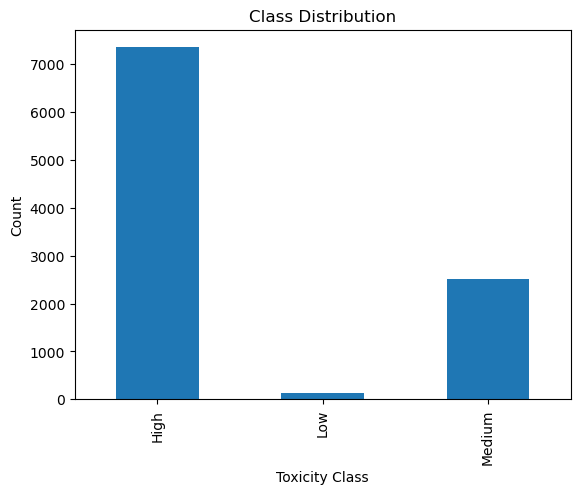

In [22]:
counts = df["toxicity"].value_counts().sort_index()
counts.plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Toxicity Class")
plt.ylabel("Count")
plt.show()

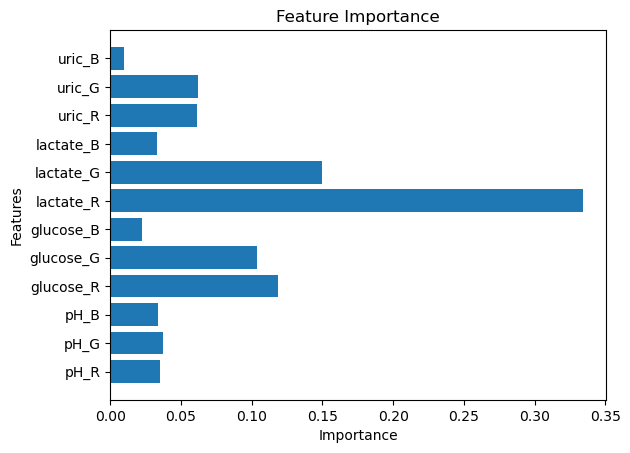

In [23]:
import numpy as np

importances = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [25]:
print("Train Accuracy:", model.score(x_train, y_train))
print("Test Accuracy:", model.score(x_test, y_test))

Train Accuracy: 0.9995
Test Accuracy: 0.9665


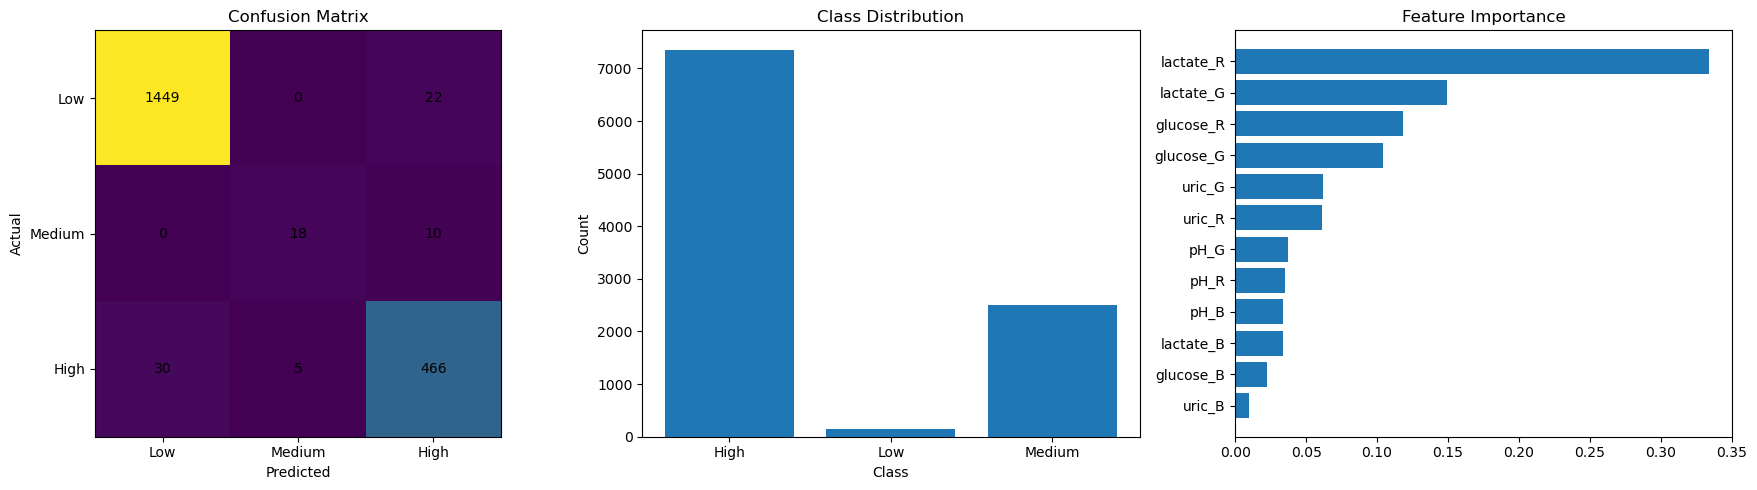

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# --- Prepare data ---
cm = confusion_matrix(y_test_decoded, y_pred_decoded)
class_counts = df["toxicity"].value_counts().sort_index()
importances = model.feature_importances_
features = X.columns

# Sort feature importance
indices = np.argsort(importances)

# --- Create subplots ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# =========================
# 1. Confusion Matrix
# =========================
axs[0].imshow(cm)
axs[0].set_title("Confusion Matrix")

classes = ["Low", "Medium", "High"]
axs[0].set_xticks(np.arange(len(classes)))
axs[0].set_yticks(np.arange(len(classes)))
axs[0].set_xticklabels(classes)
axs[0].set_yticklabels(classes)

# Add numbers
for i in range(len(classes)):
    for j in range(len(classes)):
        axs[0].text(j, i, cm[i, j],
                    ha="center", va="center")

axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("Actual")

# =========================
# 2. Class Distribution
# =========================
axs[1].bar(class_counts.index, class_counts.values)
axs[1].set_title("Class Distribution")
axs[1].set_xlabel("Class")
axs[1].set_ylabel("Count")

# =========================
# 3. Feature Importance
# =========================
axs[2].barh(features[indices], importances[indices])
axs[2].set_title("Feature Importance")

# --- Final layout ---
plt.tight_layout()
plt.show()